📘 Customer Churn Prediction

📌 Day 1: Explore & Understand the Data

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("D:/Developer Arena/week_10/customer_churn.csv")

# Basic inspection
df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


In [3]:
df.describe()

,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,36.532000,113.636000,4237.882000,0.498000,0.106000
std,20.667057,51.799903,2260.619837,0.500497,0.308146
min,1.000000,20.000000,159.000000,0.000000,0.000000
25%,19.000000,67.000000,2237.250000,0.000000,0.000000
50%,37.000000,115.000000,4182.500000,0.000000,0.000000
75%,54.000000,158.000000,6266.750000,1.000000,0.000000
max,71.000000,199.000000,7992.000000,1.000000,1.000000


In [4]:
df.isnull().sum()

CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64

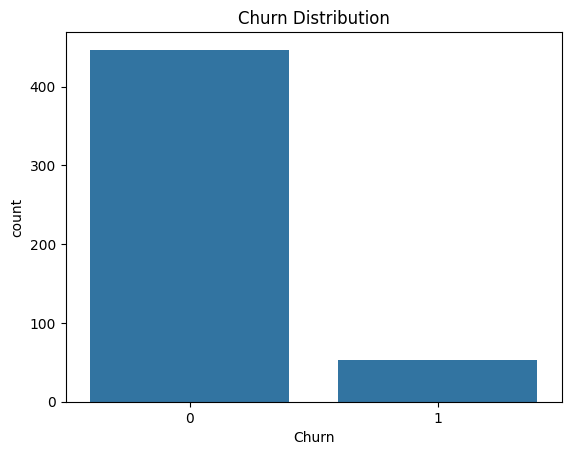

In [5]:
# Target variable distribution
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()


In [6]:
# Churn percentage
df['Churn'].value_counts(normalize=True) * 100


Churn
0    89.4
1    10.6
Name: proportion, dtype: float64

📌 Day 2: Handle Categorical Data (3 Encoding Methods)

🔹 1. Label Encoding (Binary Variables)

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['PaperlessBilling'] = le.fit_transform(df['PaperlessBilling'])


🔹 2. One-Hot Encoding (Nominal Categories)

In [14]:
df = pd.get_dummies(
    df,
    columns=['Contract', 'PaymentMethod'],
    drop_first=True
)


🔹 3. Frequency Encoding

In [15]:
df['Tenure_Frequency'] = df['Tenure'].map(
    df['Tenure'].value_counts(normalize=True)
)


📅 DAY 3: Feature Scaling (2 Techniques)

In [16]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

numeric_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']


🔹 Min-Max Scaling

In [17]:
df_minmax = df.copy()
df_minmax[numeric_cols] = MinMaxScaler().fit_transform(df[numeric_cols])


🔹 Standard Scaling

In [18]:
df_standard = df.copy()
df_standard[numeric_cols] = StandardScaler().fit_transform(df[numeric_cols])


📅 DAY 4: Outlier Detection & Handling

🔹 IQR Method

In [19]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1

df = df[
    (df['MonthlyCharges'] >= Q1 - 1.5 * IQR) &
    (df['MonthlyCharges'] <= Q3 + 1.5 * IQR)
]


🔹 Z-Score Method

In [20]:
from scipy.stats import zscore

df['z_score'] = zscore(df['MonthlyCharges'])
df = df[df['z_score'].abs() <= 3]
df.drop(columns='z_score', inplace=True)


📅 DAY 5: Feature Engineering (5+ New Features)

In [21]:
# 1. Customer Lifetime Value
df['CLV'] = df['Tenure'] * df['MonthlyCharges']

# 2. Average Monthly Spend
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['Tenure'] + 1)

# 3. High Value Customer
df['HighValueCustomer'] = (df['MonthlyCharges'] > df['MonthlyCharges'].median()).astype(int)

# 4. Long Term Customer
df['LongTermCustomer'] = (df['Tenure'] >= 24).astype(int)

# 5. Charges Ratio
df['ChargesRatio'] = df['TotalCharges'] / (df['MonthlyCharges'] + 1)


📅 DAY 6: Feature Selection

🔹 Correlation Analysis

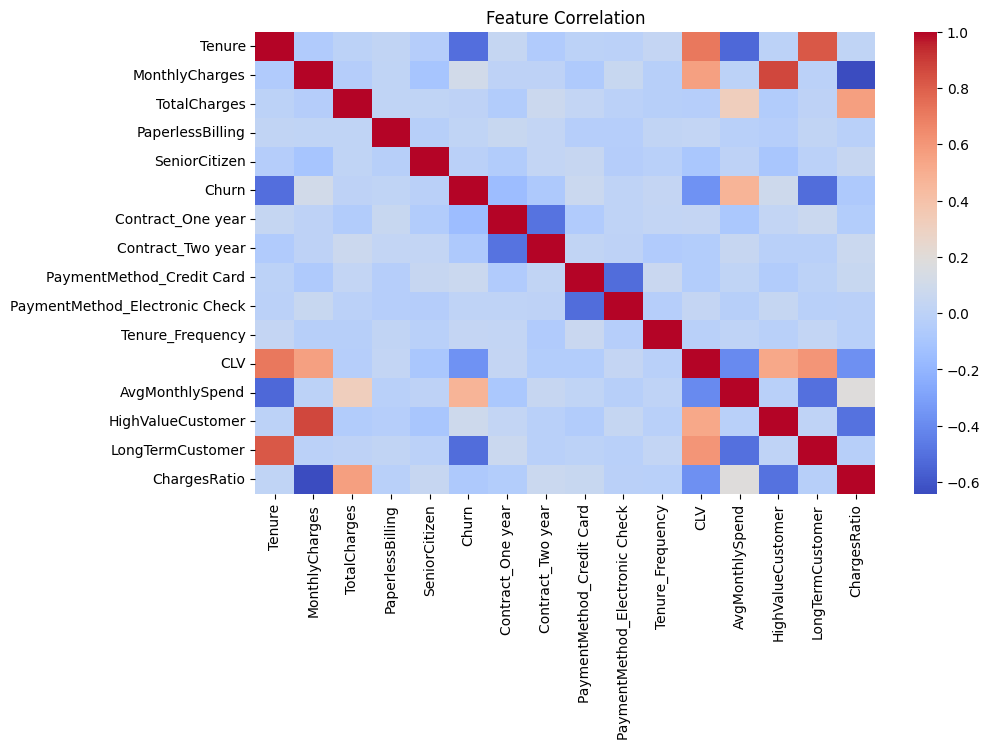

In [22]:
plt.figure(figsize=(10,6))
sns.heatmap(df.drop(columns='CustomerID').corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()


🔹 Feature Importance

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X = df.drop(['CustomerID', 'Churn'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

pd.Series(rf.feature_importances_, index=X.columns)\
    .sort_values(ascending=False)\
    .head(10)


Tenure               0.257069
AvgMonthlySpend      0.160702
CLV                  0.130018
ChargesRatio         0.087293
LongTermCustomer     0.079309
MonthlyCharges       0.073000
TotalCharges         0.058548
Tenure_Frequency     0.030021
Contract_Two year    0.028892
Contract_One year    0.027351
dtype: float64

📅 DAY 7: Complete Preprocessing Pipeline

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [25]:
numeric_features = [
    'Tenure', 'MonthlyCharges', 'TotalCharges',
    'CLV', 'AvgMonthlySpend', 'ChargesRatio'
]


In [26]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)


In [27]:
from sklearn.metrics import classification_report

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      1.00      0.97        84
           1       1.00      0.62      0.77        16

    accuracy                           0.94       100
   macro avg       0.97      0.81      0.87       100
weighted avg       0.94      0.94      0.93       100

